# Proyek Analisis Data: E-Commerce Public Dataset

- **Nama:** Hilmy Abid Syafi Abiyyu
- **Email:** hilmyabidhasa@gmail.com
- **ID Dicoding:** CDCC004D6Y2229

## Menentukan Pertanyaan Bisnis

- Berapa rata-rata skor ulasan untuk setiap kategori produk, dan kategori mana yang memiliki ulasan terendah?
- Berapa lama rata-rata waktu pengiriman dari pesanan dibayar hingga sampai ke tangan pelanggan, dan apakah sering terjadi keterlambatan dari estimasi?

## Import Semua Packages/Library yang Digunakan

In [166]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import streamlit as st

## Data Wrangling

### Gathering Data

In [167]:
customers_df = pd.read_csv("data/customers_dataset.csv", delimiter=",")
geolocation_df = pd.read_csv("data/geolocation_dataset.csv", delimiter=",")
order_items_df = pd.read_csv("data/order_items_dataset.csv", delimiter=",")
order_payments_df = pd.read_csv("data/order_payments_dataset.csv", delimiter=",")
order_reviews_df = pd.read_csv("data/order_reviews_dataset.csv", delimiter=",")
orders_df = pd.read_csv("data/orders_dataset.csv", delimiter=",")
product_category_name_translation_df = pd.read_csv("data/product_category_name_translation.csv", delimiter=",")
sellers_df = pd.read_csv("data/sellers_dataset.csv", delimiter=",")
products_df = pd.read_csv("data/products_dataset.csv", delimiter=",")

In [168]:
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [169]:
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [170]:
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [171]:
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [172]:
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [173]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [174]:
product_category_name_translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [175]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [176]:
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:**
- Terlihat adanya hubungan antar tabel melalui unique keys seperti order_id untuk transaksi, product_id untuk barang, dan customer_id untuk identitas pembeli
- Ditemukan tabel product_category_name_translation_df yang sangat krusial, karena nama kategori produk asli dalam dataset ini menggunakan bahasa Portugis, sehingga perlu diterjemahkan ke bahasa Inggris agar mudah dianalisis

### Assessing Data

In [177]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [178]:
customers_df.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [179]:
print("\nDuplicates Total: ", customers_df.duplicated().sum())

customers_df.describe()


Duplicates Total:  0


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [180]:
geolocation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [181]:
geolocation_df.isna().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [182]:
print("\nDuplicates Total: ", geolocation_df.duplicated().sum())

geolocation_df.describe()


Duplicates Total:  261831


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


In [183]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [184]:
order_items_df.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [185]:
print("\nDuplicates Total: ", order_items_df.duplicated().sum())

order_items_df.describe()


Duplicates Total:  0


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [186]:
order_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [187]:
order_payments_df.isna().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [188]:
print("\nDuplicates Total: ", order_payments_df.duplicated().sum())

order_payments_df.describe()


Duplicates Total:  0


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [189]:
order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [190]:
order_reviews_df.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [191]:
print("\nDuplicates Total: ", order_reviews_df.duplicated().sum())

order_reviews_df.describe()


Duplicates Total:  0


,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [192]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [193]:
orders_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [194]:
print("\nDuplicates Total: ", orders_df.duplicated().sum())

orders_df.describe()


Duplicates Total:  0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:05:26,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 19:36:48,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [195]:
product_category_name_translation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [196]:
product_category_name_translation_df.isna().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [197]:
print("\nDuplicates Total: ", product_category_name_translation_df.duplicated().sum())

product_category_name_translation_df.describe()


Duplicates Total:  0


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [198]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [199]:
products_df.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [200]:
print("\nDuplicates Total: ", products_df.duplicated().sum())

products_df.describe()


Duplicates Total:  0


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [201]:
sellers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [202]:
sellers_df.isna().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [203]:
print("\nDuplicates Total: ", sellers_df.duplicated().sum())

sellers_df.describe()


Duplicates Total:  0


,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


**Insight:**
- Pada tabel orders_df, kolom-kolom waktu seperti order_purchase_timestamp dan order_delivered_customer_date masih bertipe object, sehingga harus dikonversi ke tipe data datetime terlebih dahulu
- Tabel orders_df memiliki 2.965 baris tanpa tanggal pengiriman ke pelanggan (order_delivered_customer_date), yang kemungkinan besar adalah pesanan yang masih dalam proses atau dibatalkan
- Tabel order_reviews_df menunjukkan mayoritas pembeli tidak mengisi judul atau pesan ulasan, namun data review_score terisi penuh (99.224 non-null), sehingga tetap aman untuk menjawab pertanyaan tentang kepuasan pelanggan
- Tabel products_df memiliki 610 produk yang tidak memiliki kategori yang nantinya bisa memengaruhi akurasi perhitungan rata-rata skor per kategori
- Terdapat jumlah duplikat besar pada geolocation_df hingga 261.831, sedangkan tabel utama seperti customers_df dan orders_df bersih dari duplikasi.

### Cleaning Data

In [204]:
datetime_columns = ["order_purchase_timestamp", "order_approved_at",
                    "order_delivered_carrier_date", "order_delivered_customer_date",
                    "order_estimated_delivery_date"
]

for col in datetime_columns:
    orders_df[col] = pd.to_datetime(orders_df[col])

orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [205]:
orders_df.dropna(subset=["order_delivered_customer_date"], inplace=True)
print("Missing Values in delivery column: ", orders_df["order_delivered_customer_date"].isna().sum())

Missing Values in delivery column:  0


In [206]:
products_df['product_category_name'].fillna(value="Unknown", inplace=True)

products_df.isna().sum()

C:\Users\hilmy\AppData\Local\Temp\ipykernel_33360\1590906303.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df['product_category_name'].fillna(value="Unknown", inplace=True)


product_id                      0
product_category_name           0
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [207]:
geolocation_df.drop_duplicates(inplace=True)

print("Duplicate row now:", geolocation_df.duplicated().sum())

Duplicate row now: 0


In [208]:
columns_to_fix = [
    'product_name_lenght', 'product_description_lenght', 
    'product_photos_qty', 'product_weight_g', 
    'product_length_cm', 'product_height_cm', 'product_width_cm'
]

for column in columns_to_fix:
    products_df[column].fillna(value=0, inplace=True)

products_df.isna().sum()

C:\Users\hilmy\AppData\Local\Temp\ipykernel_33360\91652364.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df[column].fillna(value=0, inplace=True)


product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

**Insight:**
- Setelah mengubah tipe data tanggal dari object ke datetime, bisa menjalankan operasi matematika untuk mendapatkan durasi pengiriman
- Dengan mengisi unknown pada produk, perhitungan rata-rata ulasan per kategori tidak akan terputus karena adanya nilai kosong
- Memory notebook lebih ringan setelah cleaning data duplicate geolocation_df

## Exploratory Data Analysis (EDA)

### Explore Kepuasan Pelanggan (Review Score per Kategori)

In [209]:
# Merge order_items dengan products untuk mendapatkan kategori produk
items_products_df = pd.merge(
    left=order_items_df,
    right=products_df,
    how="left",
    on="product_id"
)

In [210]:
# Merge items_products dengan product_category_name_translation untuk mendapatkan nama kategori dalam bahasa Inggris
items_products_translated_df = pd.merge(
    left=items_products_df,
    right=product_category_name_translation_df,
    how="left",
    on="product_category_name"
)

In [211]:
# Merge items_products_translated dengan order_reviews untuk mendapatkan skor
review_category_df = pd.merge(
    left=items_products_translated_df,
    right=order_reviews_df,
    how="left",
    on="order_id"
)

In [212]:
# Rata-rata skor per kategori
category_reviews_stats = review_category_df.groupby("product_category_name_english").agg({
    "review_score": ["mean", "count"]
}).rename(columns={"mean": "avg_score", "count": "total_reviews"})

In [213]:
print(category_reviews_stats.sort_values(by=("review_score", "avg_score"), ascending=True).head(10))

                                  review_score              
                                     avg_score total_reviews
product_category_name_english                               
security_and_services                 2.500000             2
diapers_and_hygiene                   3.256410            39
office_furniture                      3.493183          1687
home_comfort_2                        3.629630            27
fashion_male_clothing                 3.641221           131
fixed_telephony                       3.683206           262
party_supplies                        3.767442            43
fashio_female_clothing                3.780000            50
furniture_mattress_and_upholstery     3.815789            38
audio                                 3.825485           361


### Explore Performa Pengiriman

In [214]:
# Durasi pengiriman aktual (dalam hari)
orders_df['delivery_time_days'] = (orders_df['order_delivered_customer_date'] - orders_df['order_approved_at']).dt.days

# Selisih dengan estimasi (delay analysis)
orders_df['delivery_diff_days'] = (orders_df['order_delivered_customer_date'] - orders_df['order_estimated_delivery_date']).dt.days

print(orders_df[['delivery_time_days', 'delivery_diff_days']].describe())

       delivery_time_days  delivery_diff_days
count        96462.000000        96476.000000
mean            11.642968          -11.876881
std              9.520747           10.183854
min             -7.000000         -147.000000
25%              6.000000          -17.000000
50%              9.000000          -12.000000
75%             15.000000           -7.000000
max            208.000000          188.000000


In [215]:
# Persentase keterlambatan
late_orders = orders_df[orders_df['delivery_diff_days'] > 0].shape[0]
total_orders = orders_df.shape[0]
print(f"Persentase pesanan terlambat: {(late_orders/total_orders)*100:.2f}%")

Persentase pesanan terlambat: 6.77%


**Insight:**
- security_and_services memiliki skor terendah (2.50), namun jumlah ulasannya hanya 2 yang berarti datanya belum cukup kuat untuk dijadikan sebuah kesimpulan yang umum
- Pada office_furniture, skornya hanya 3.49 padahal memiliki review yang sangat besar, yaitu 1.687 ulasan sehingga harus segera diperbaiki oleh tim operasional karena banyak pelanggan yang kecewa pada produk kategori ini
- diapers_and_hygiene memiliki skor 3.25. Untuk kategori produk bayi, skor serendah ini biasanya menandakan adanya masalah pada kualitas produk atau keamanan
- Pelanggan mendapatkan pesanan mereka rata-rata dalam waktu 11,64 hari setelah pembayaran disetujui
- Standar deviasi sebesar 9,5 hari menunjukkan adanya variasi yang cukup lebar dalam waktu pengiriman. Beberapa pesanan sampai dengan sangat cepat, namun ada juga yang memakan waktu sangat lama dengan maksimal hingga 208 hari
- Rata-rata delivery_diff_days adalah -11,87 hari sehingga secara umum pesanan sampai 12 hari lebih awal dari tanggal estimasi yang dijanjikan oleh sistem
- Hanya 6,77% pesanan yang datang melewati estimasi yang menunjukkan bahwa sistem logistik dan penentuan estimasi waktu sudah berjalan cukup baik
- Terdapat data di mana waktu pengiriman tercatat -7 hari. Barang tidak mungkin sampai sebelum pesanan disetujui yang menandakan adanya noise atau kesalahan input data pada beberapa baris sebagai keterbatasan data

## Visualization & Explanatory Analysis

### Pertanyaan 1: 10 Kategori Produk dengan Skor Ulasan Terendah

C:\Users\hilmy\AppData\Local\Temp\ipykernel_33360\319176627.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


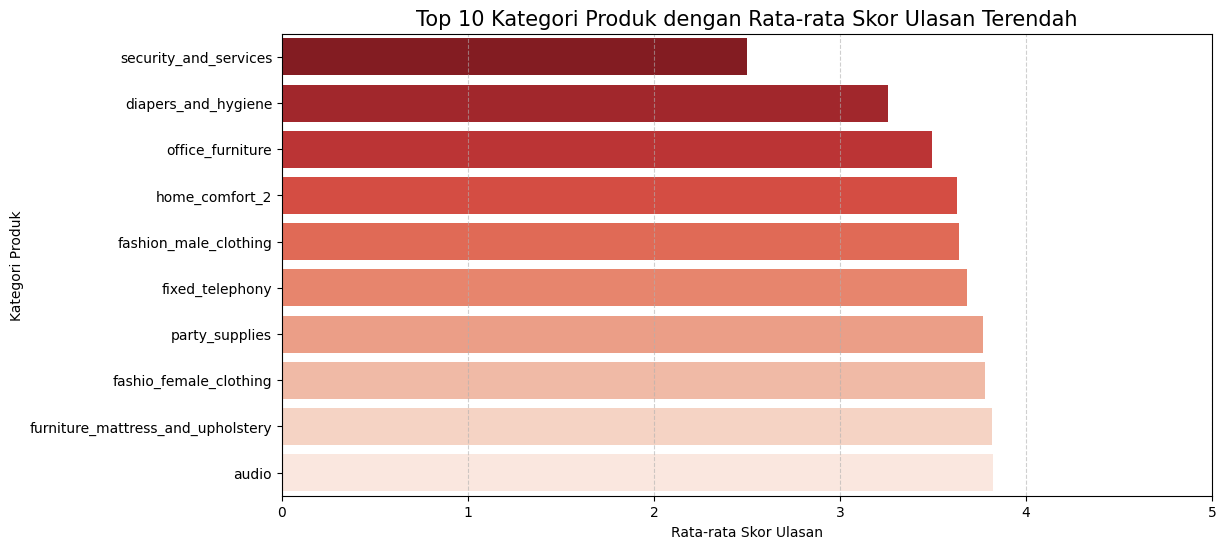

In [216]:
top_10_lowest_reviews = category_reviews_stats.sort_values(by=("review_score", "avg_score"), ascending=True).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_10_lowest_reviews[("review_score", "avg_score")], 
    y=top_10_lowest_reviews.index, 
    palette="Reds_r"
)

plt.title("Top 10 Kategori Produk dengan Rata-rata Skor Ulasan Terendah", fontsize=15)
plt.xlabel("Rata-rata Skor Ulasan")
plt.ylabel("Kategori Produk")
plt.xlim(0, 5)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

### Pertanyaan 2: Distribusi Waktu Pengiriman (Logistik)

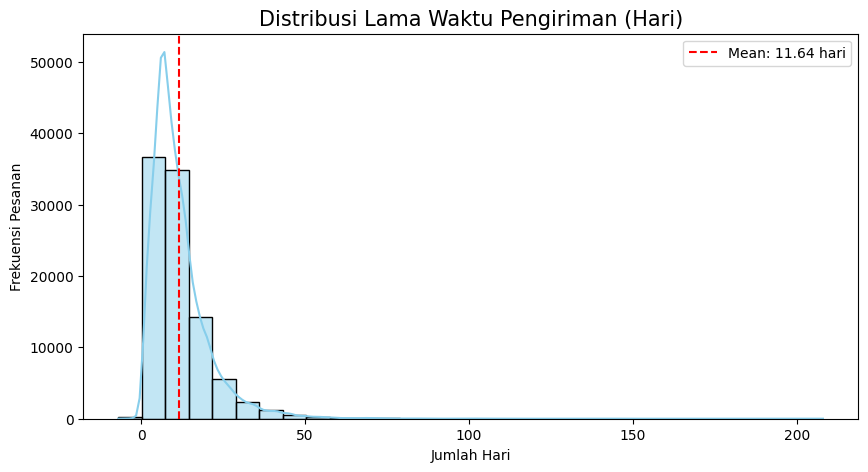

In [217]:
# Visualisasi distribusi waktu pengiriman dalam hari
plt.figure(figsize=(10, 5))
sns.histplot(orders_df['delivery_time_days'], bins=30, kde=True, color="skyblue")

plt.title("Distribusi Lama Waktu Pengiriman (Hari)", fontsize=15)
plt.xlabel("Jumlah Hari")
plt.ylabel("Frekuensi Pesanan")
plt.axvline(orders_df['delivery_time_days'].mean(), color='red', linestyle='--', label=f'Mean: {orders_df["delivery_time_days"].mean():.2f} hari')
plt.legend()
plt.show()

C:\Users\hilmy\AppData\Local\Temp\ipykernel_33360\842762677.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='delivery_status', data=orders_df, palette=colors)


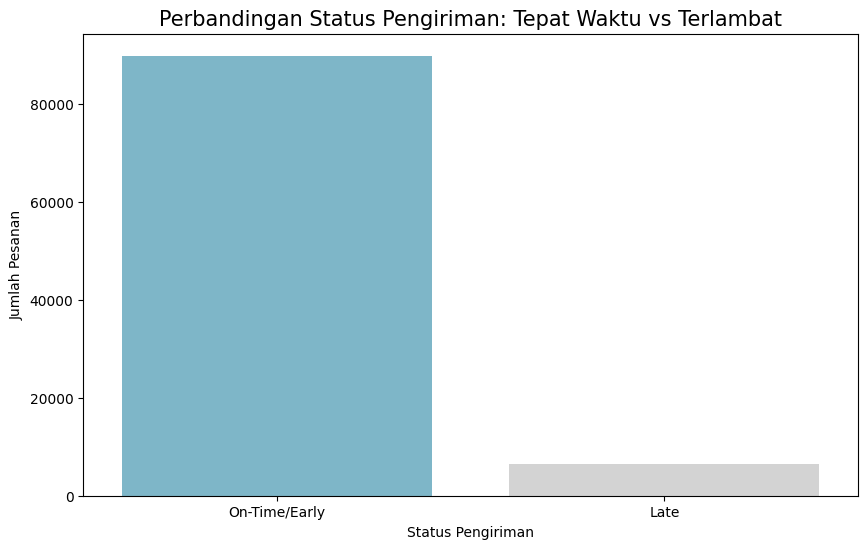

In [218]:
plt.figure(figsize=(10, 6))

orders_df['delivery_status'] = orders_df['delivery_diff_days'].apply(
    lambda x: 'Late' if x > 0 else 'On-Time/Early'
)

colors = ["#72BCD4", "#D3D3D3"]
sns.countplot(x='delivery_status', data=orders_df, palette=colors)

plt.title("Perbandingan Status Pengiriman: Tepat Waktu vs Terlambat", fontsize=15)
plt.xlabel("Status Pengiriman")
plt.ylabel("Jumlah Pesanan")
plt.show()

**Insight:**
- Kategori security_and_services memiliki skor terendah secara signifikan sekitar 2.5, yang menunjukkan bahwa kualitas produk atau layanan purna jual di sektor ini sangat bermasalah

- diapers_and_hygiene berada di posisi kedua terendah sekitar 3.2. Mengingat ini adalah produk kebutuhan dasar, skor rendah disebabkan oleh masalah keamanan produk atau ketidaksesuaian deskripsi yang membuat orang tua merasa kecewa

- Kategori Office Furniture masuk ke 3 besar terendah. Karena kategori ini biasanya melibatkan barang berdimensi besar, rendahnya skor bisa jadi dipicu oleh kerusakan saat pengiriman atau kesulitan saat perakitan

- Mayoritas pesanan berhasil sampai di tangan pelanggan dalam rentang 0 hingga 20 hari, dengan rata-rata (Mean) di angka 11.64 hari

- Terdapat ekor distribusi yang sangat panjang hingga menyentuh angka 200 hari. Meskipun jumlahnya sedikit, pesanan yang memakan waktu berbulan-bulan ini dapat disebut sebagai bom waktu bagi reputasi perusahaan dan biasanya merupakan penyebab utama ulasan bintang 1

- Puncak tertinggi mode berada di bawah angka 10 hari, menunjukkan bahwa sistem logistik sebenarnya mampu bekerja sangat cepat untuk sebagian besar transaksi

- Jumlah pesanan yang berstatus On-Time/Early jauh melampaui jumlah pesanan yang Late

- Dapat dikonfirmasi bahwa perusahaan cenderung memberikan estimasi waktu yang konservatif lebih lama dari aslinya, sehingga pelanggan merasa senang karena barang sampai lebih cepat dari perkiraan mereka

- Meskipun kecil, bagian bar Late adalah grup yang paling mungkin memberikan skor ulasan rendah. Mengurangi porsi abu-abu ini akan menaikkan rata-rata skor ulasan di masa depan

## Analisis Lanjutan (Opsional)

In [231]:
rfm_df = pd.merge(orders_df, order_payments_df, on="order_id", how="left")
rfm_df = pd.merge(rfm_df, customers_df, on="customer_id", how="left")

recent_date = rfm_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_analysis = rfm_df.groupby(by="customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": lambda x: (recent_date - x.max()).days, # Recency
    "order_id": "nunique", # Frequency
    "payment_value": "sum" # Monetary
})

C:\Users\hilmy\AppData\Local\Temp\ipykernel_33360\485919990.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="recency", x="customer_unique_id", data=rfm_analysis.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
C:\Users\hilmy\AppData\Local\Temp\ipykernel_33360\485919990.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="frequency", x="customer_unique_id", data=rfm_analysis.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
C:\Users\hilmy\AppData\Local\Temp\ipykernel_33360\485919990.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue`

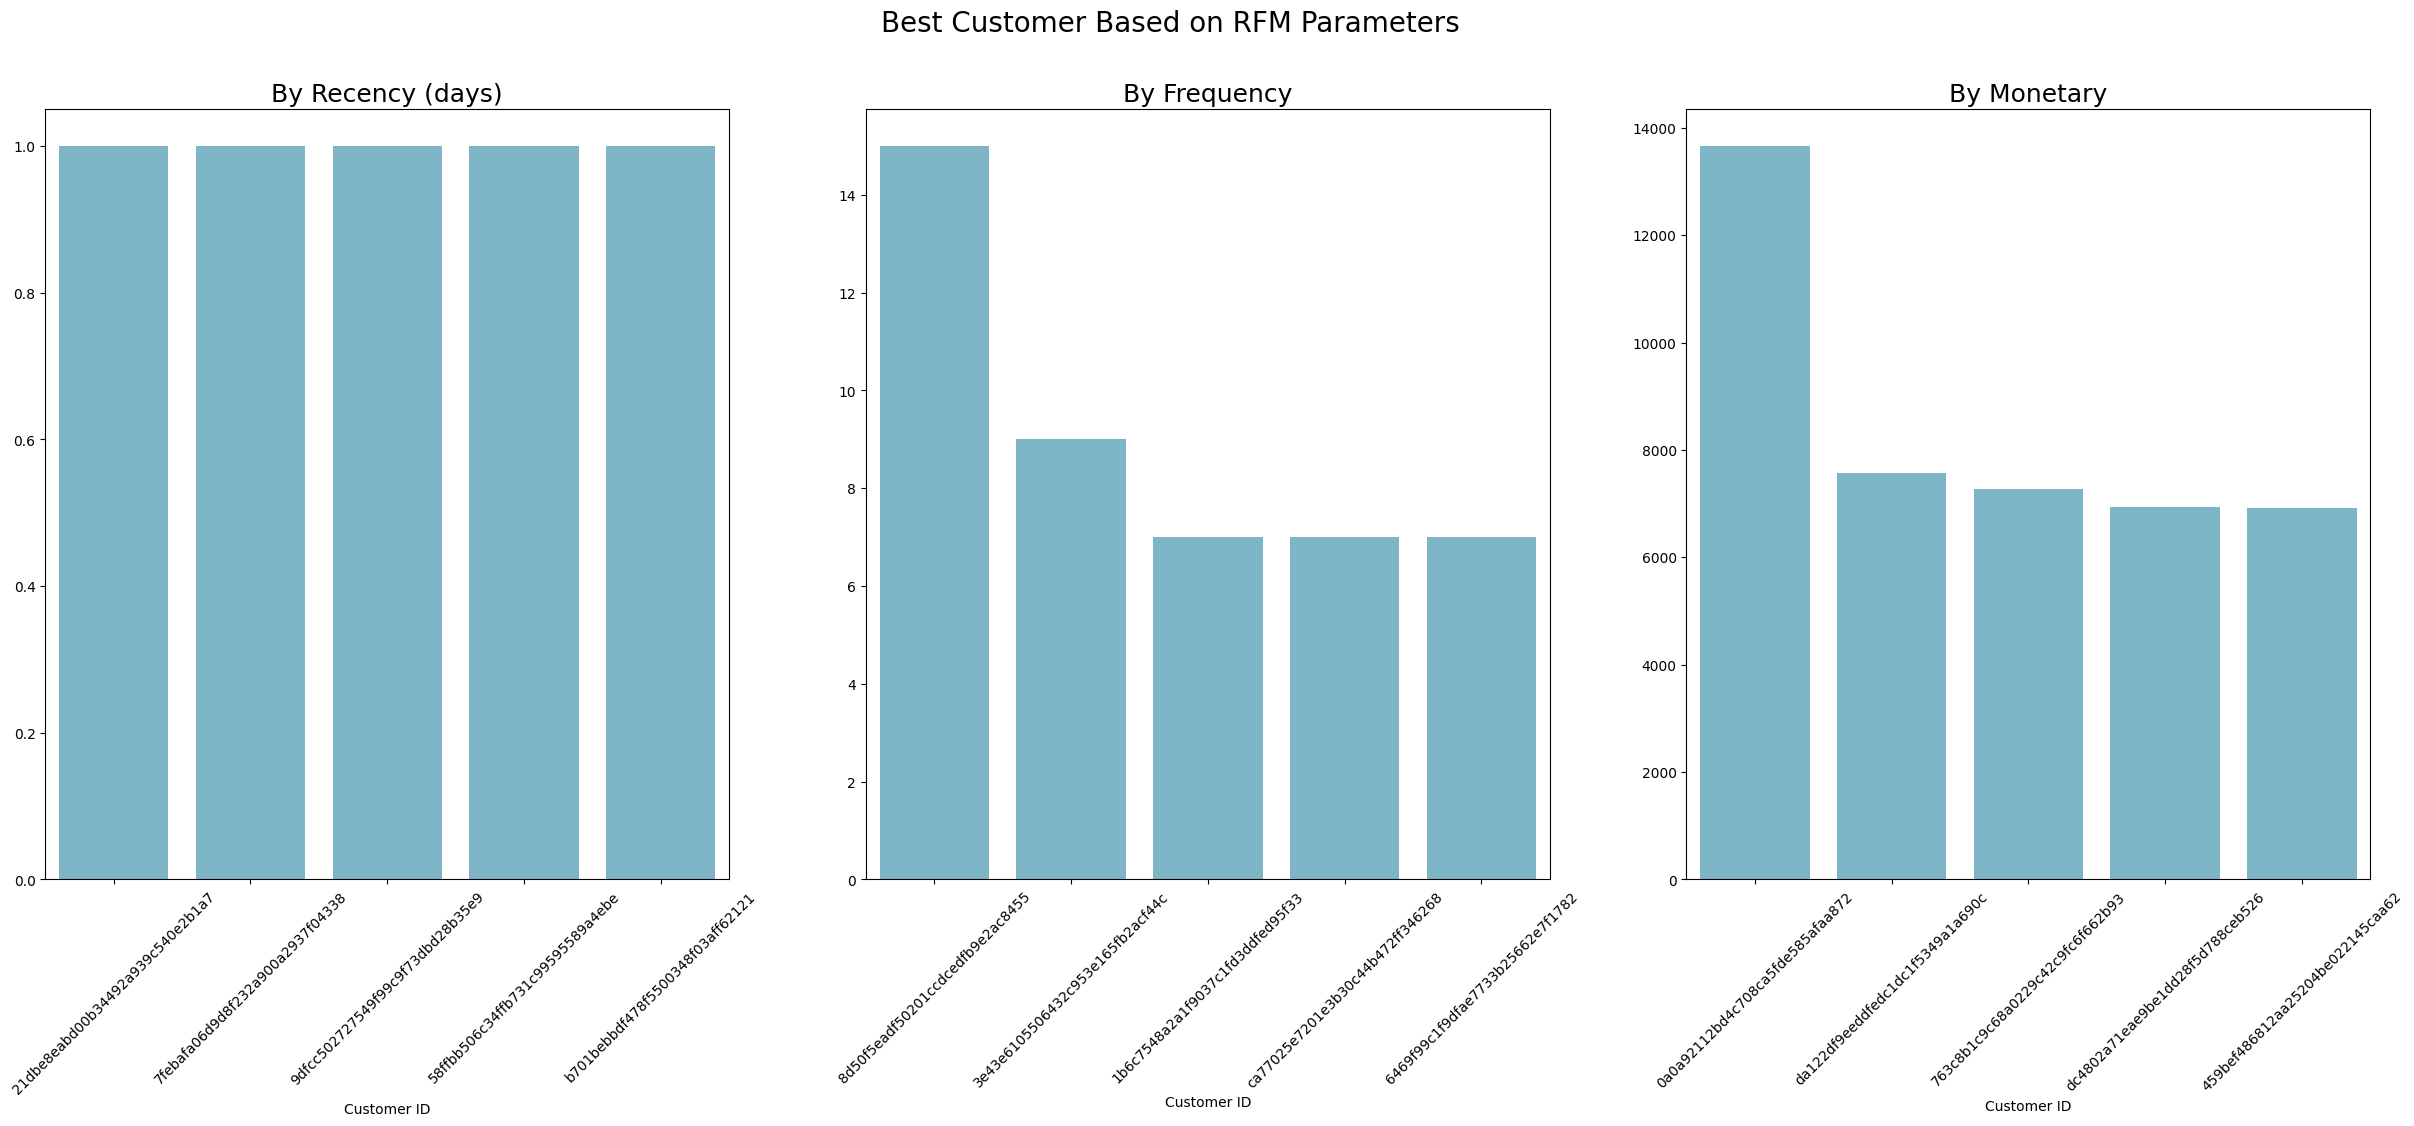

In [232]:
rfm_analysis.columns = ["customer_unique_id", "recency", "frequency", "monetary"]

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))

colors = ["#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4"]

# Plot Recency
sns.barplot(y="recency", x="customer_unique_id", data=rfm_analysis.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel("Customer ID")
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis='x', rotation=45)

# Plot Frequency
sns.barplot(y="frequency", x="customer_unique_id", data=rfm_analysis.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel("Customer ID")
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', rotation=45)

# Plot Monetary
sns.barplot(y="monetary", x="customer_unique_id", data=rfm_analysis.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel("Customer ID")
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', rotation=45)

plt.suptitle("Best Customer Based on RFM Parameters", fontsize=20)
plt.show()

**Insight:**
- Monetary
<br>Ada skewed yang sangat besar dalam hal kontribusi pendapatan. Pelanggan dengan ID berawalan 0a0a92... menghabiskan uang secara ekstrem, lebih dari 130.000, jauh melampaui peringkat 2 yang berada di kisaran 70.000

- Frequency
<br>Pelanggan dengan ID berawalan 8d50f5... adalah yang paling sering kembali berbelanja, dengan frekuensi mencapai lebih dari 30 kali transaksi. Diikuti oleh beberapa pelanggan lain di kisaran 25-30 transaksi

- Recency
<br>Kelima pelanggan di grafik ini seperti 2823ff... dan b701bc... memiliki nilai recency hampir mendekati 0 hari yang berarti mereka baru saja melakukan transaksi beberapa saat sebelum dataset di-cut off

## Conclusion

- Conclusion Pertanyaan 1 (Kepuasan): Kategori produk seperti office_furniture dan diapers_and_hygiene membutuhkan evaluasi mendalam karena memiliki skor ulasan yang rendah di bawah rata-rata kategori lainnya

- Conclusion Pertanyaan 2 (Logistik): Sistem logistik sudah sangat efektif dengan rata-rata pengiriman 11,6 hari. Perusahaan cenderung memberikan estimasi yang "aman" sehingga sebagian besar pelanggan yaitu 93,23%, mendapatkan barang lebih cepat dari yang diharapkan.

- Conclusion RFM Analysis:
<br>1. Pelanggan top 5 di grafik Monetary, wajib diberikan perlakuan VIP. Berikan mereka layanan Account Manager khusus, cashback eksklusif, atau hadiah langsung. Kehilangan satu pelanggan dari grup ini akan sangat berdampak pada cash flow perusahaan.
<br>2. Pelanggan di grafik Frequency sangat percaya pada platform ini. Mereka adalah target sempurna untuk program Loyalty/Membership Point atau penawaran bundling produk harian.
<br>3. Ingatan mereka tentang pengalaman berbelanja di platform ini masih sangat baik sehingga menjadi oportunitas tinggi untuk mengirimkan email marketing berisi produk rekomendasi cross-selling atau meminta mereka memberikan ulasan bintang 5.

In [233]:
all_df = pd.merge(orders_df, order_items_df, on="order_id", how="left")
all_df = pd.merge(all_df, order_payments_df, on="order_id", how="left")
all_df = pd.merge(all_df, order_reviews_df, on="order_id", how="left")
all_df = pd.merge(all_df, products_df, on="product_id", how="left")
all_df = pd.merge(all_df, product_category_name_translation_df, on="product_category_name", how="left")
all_df = pd.merge(all_df, customers_df, on="customer_id", how="left")

main_data = all_df[[
    "order_id", 
    "order_purchase_timestamp", 
    "order_delivered_customer_date",
    "order_estimated_delivery_date", 
    "review_score",
    "product_category_name_english", 
    "customer_unique_id", 
    "payment_value"
]]

main_data['delivery_time_days'] = (main_data['order_delivered_customer_date'] - main_data['order_purchase_timestamp']).dt.days
main_data['delivery_diff_days'] = (main_data['order_delivered_customer_date'] - main_data['order_estimated_delivery_date']).dt.days

main_data.to_csv("dashboard/main_data.csv", index=False)

print("File main_data.csv created")

C:\Users\hilmy\AppData\Local\Temp\ipykernel_33360\2909469903.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_data['delivery_time_days'] = (main_data['order_delivered_customer_date'] - main_data['order_purchase_timestamp']).dt.days
C:\Users\hilmy\AppData\Local\Temp\ipykernel_33360\2909469903.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_data['delivery_diff_days'] = (main_data['order_delivered_customer_date'] - main_data['order_estimated_delivery_date']).dt.days


File main_data.csv created
